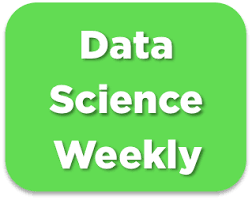

# Challenge : predict conversions 🏆🏆

This is the template that shows the different steps of the challenge. In this notebook, all the training/predictions steps are implemented for a very basic model (logistic regression with only one variable). Please use this template and feel free to change the preprocessing/training steps to get the model with the best f1-score ! May the force be with you 🧨🧨  

**For a detailed description of this project, please refer to *02-Conversion_rate_challenge.ipynb*.**

# Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE
from IPython.display import display

# Read file with labels

In [2]:
data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

Set with labels (our train+test) : (284580, 6)


In [3]:
data.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


# Explore dataset

In [4]:
# The dataset is quite big : you must create a sample of the dataset before making any visualizations !
data_sample = data.sample(10000)

# Make your model

## Choose variables to use in the model, and create train and test sets
**From the EDA, we know that the most useful feature is total_pages_visited. Let's create a baseline model by using at first only this feature : in the next cells, we'll make preprocessings and train a simple (univariate) logistic regression.**

In [5]:
features_list = ['total_pages_visited']
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'

In [6]:
X = data.loc[:, features_list]
Y = data.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['total_pages_visited'], dtype='object')



In [7]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



## Training pipeline

In [8]:
# Put here all the preprocessings
print("Encoding categorical features and standardizing numerical features...")

featureencoder = StandardScaler()
X_train = featureencoder.fit_transform(X_train)
print("...Done")
print(X_train[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[-0.26070136]
 [ 0.93728655]
 [-0.85969532]
 [-0.56019834]
 [-0.26070136]]


In [9]:
# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [10]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



## Test pipeline

In [11]:
# Use X_test, and the same preprocessings as in training pipeline, 
# but call "transform()" instead of "fit_transform" methods (see example below)

print("Encoding categorical features and standardizing numerical features...")

X_test = featureencoder.transform(X_test)
print("...Done")
print(X_test[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 0.63778957]
 [ 0.03879562]
 [-0.26070136]
 [-0.26070136]
 [ 0.63778957]]


In [12]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]



## Performance assessment

In [13]:
# WARNING : Use the same score as the one that will be used by Kaggle !
# Here, the f1-score will be used to assess the performances on the leaderboard
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.6938517686692869
f1-score on test set :  0.7060240963855422


In [14]:
# You can also check more performance metrics to better understand what your model is doing
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[246817   1082]
 [  3280   4943]]

Confusion matrix on test set : 
[[27384   117]
 [  371   586]]



**Our baseline model reaches a f1-score of almost 70%. Now, feel free to refine your model and try to beat this score ! 🚀🚀**

# Train best classifier on all data and use it to make predictions on X_without_labels
**Before making predictions on the file conversion_data_test.csv, let's train our model on ALL the data that was in conversion_data_train.csv. Sometimes, this allows to make tiny improvements in the score because we're using more examples to train the model.**

In [15]:
# Concatenate our train and test set to train your best classifier on all data with labels
X = np.append(X_train,X_test,axis=0)
Y = np.append(Y_train,Y_test)

classifier.fit(X,Y)

LogisticRegression()

In [16]:
# Read data without labels
data_without_labels = pd.read_csv('conversion_data_test.csv')
print('Prediction set (without labels) :', data_without_labels.shape)

# Warning : check consistency of features_list (must be the same than the features 
# used by your best classifier)
features_list = ['total_pages_visited']
X_without_labels = data_without_labels.loc[:, features_list]

# Convert pandas DataFrames to arrays before using scikit-learn
print("Convert pandas DataFrames to arrays...")
X_without_labels = X_without_labels.values
print("...Done")

print(X_without_labels[0:5,:])

Prediction set (without labels) : (31620, 5)
Convert pandas DataFrames to arrays...
...Done
[[16]
 [ 5]
 [ 1]
 [ 6]
 [ 3]]


In [17]:
# WARNING : PUT HERE THE SAME PREPROCESSING AS FOR YOUR TEST SET
# CHECK YOU ARE USING X_without_labels
print("Encoding categorical features and standardizing numerical features...")

X_without_labels = featureencoder.transform(X_without_labels)
print("...Done")
print(X_without_labels[0:5,:])

Encoding categorical features and standardizing numerical features...
...Done
[[ 3.33326238]
 [ 0.03879562]
 [-1.15919229]
 [ 0.3382926 ]
 [-0.56019834]]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names



In [18]:
# Make predictions and dump to file
# WARNING : MAKE SURE THE FILE IS A CSV WITH ONE COLUMN NAMED 'converted' AND NO INDEX !
# WARNING : FILE NAME MUST HAVE FORMAT 'conversion_data_test_predictions_[name].csv'
# where [name] is the name of your team/model separated by a '-'
# For example : [name] = AURELIE-model1
data = {
    'converted': classifier.predict(X_without_labels)
}

Y_predictions = pd.DataFrame(columns=['converted'],data=data)
Y_predictions.to_csv('conversion_data_test_predictions_EXAMPLE.csv', index=False)


## Analyzing the coefficients and interpreting the result
**In this template, we just trained a model with only one feature (total_pages_visited), so there's no analysis to be done about the feature importance 🤔**

**Once you've included more features in your model, please take some time to analyze the model's parameters and try to find some lever for action to improve the newsletter's conversion rate 😎😎**

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
# --- AJOUTER LES FONCTIONS DE MÉTRIQUES ---
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix 
import numpy as np

# --- 1. PRÉPARATION DES DONNÉES ET DIVISION EN TRAIN/TEST ---
dataset = pd.read_csv('conversion_data_train.csv')
features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = 'converted'

X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

# ### AJOUTER LE SPLIT pour créer un ensemble de test AVEC étiquettes connues
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, stratify=Y, random_state=0)
print(f"Tailles (Train/Test) après division: X_train: {X_train.shape}, X_test: {X_test.shape}")


# Redéfinition du ColumnTransformer
numerical_features = ['age', 'total_pages_visited']
categorical_features = ['country', 'new_user', 'source'] 

featureencoder = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)
classifier_rf = RandomForestClassifier(random_state=0, n_jobs=-1, n_estimators=100) 

# Prétraitement sur l'ensemble d'ENTRAÎNEMENT (X_train)
print("Prétraitement de l'ensemble de données d'entraînement...")
X_train_processed = featureencoder.fit_transform(X_train) 
X_test_processed = featureencoder.transform(X_test) # Transformation du TEST
print("...Terminé.")

# --- 2. ENTRAÎNEMENT DU MODÈLE (sur l'ensemble d'entraînement) ---
print("Entraînement du Random Forest sur les données d'entraînement...")
classifier_rf.fit(X_train_processed, Y_train) 
print("...Modèle entraîné.")


# --- 3. ÉVALUATION DES RÉSULTATS SUR L'ENSEMBLE DE TEST (X_test) ---

# Prédiction sur l'ensemble de test
Y_predictions_test = classifier_rf.predict(X_test_processed)

# ### CALCULER ET AFFICHER LE F1-SCORE
f1_test = f1_score(Y_test, Y_predictions_test)

print("\n--- RÉSULTATS DE PERFORMANCE SUR L'ENSEMBLE DE TEST (Évaluation) ---")
print(f"**F1-Score : {f1_test:.4f}**")
print(f"Rappel : {recall_score(Y_test, Y_predictions_test):.4f}")
print(f"Précision : {precision_score(Y_test, Y_predictions_test):.4f}")
print("Matrice de Confusion :\n", confusion_matrix(Y_test, Y_predictions_test))

# --- 4. PRÉDICTIONS ET EXPORT (sur le fichier sans étiquettes 'conversion_data_test.csv') ---
# (Cette partie reste identique pour générer le fichier de soumission)
data_without_labels = pd.read_csv('conversion_data_test.csv')
X_without_labels = data_without_labels.loc[:, features_list]
X_without_labels_processed = featureencoder.transform(X_without_labels)
Y_predictions_rf = classifier_rf.predict(X_without_labels_processed)

predictions_df = pd.DataFrame(
    {'converted': Y_predictions_rf}
)

# WARNING: Remplacer [VOTRE-NOM] par un nom d'équipe unique !
#predictions_df.to_csv('conversion_data_test_predictions_evaluation.csv', index=False) 
#print("\nFichier de soumission créé pour 'conversion_data_test.csv'.")

Tailles (Train/Test) après division: X_train: (241893, 5), X_test: (42687, 5)
Prétraitement de l'ensemble de données d'entraînement...
...Terminé.
Entraînement du Random Forest sur les données d'entraînement...
...Modèle entraîné.

--- RÉSULTATS DE PERFORMANCE SUR L'ENSEMBLE DE TEST (Évaluation) ---
**F1-Score : 0.7428**
Rappel : 0.6826
Précision : 0.8146
Matrice de Confusion :
 [[41096   214]
 [  437   940]]


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
import numpy as np

# --- PARAMÈTRES OPTIMAUX (Tirés des étapes précédentes) ---
BEST_RF_PARAMS = {'max_depth': 12, 'min_samples_leaf': 7, 'n_estimators': 250}
BEST_THRESHOLD = 0.43 # Seuil optimal pour maximiser le F1-Score

# --- 1. PRÉPARATION DES DONNÉES ET DIVISION EN TRAIN/TEST ---
dataset = pd.read_csv('conversion_data_train.csv')
features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = 'converted'

X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

# Division des données pour l'évaluation
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15, random_state=0)
print(f"Tailles (Train/Test) après division: X_train: {X_train.shape}, X_test: {X_test.shape}")

# --- 2. TARGET ENCODING POUR 'country' (Optimisation Clé) ---
print("\nApplication du Target Encoding sur 'country'...")
# Calcul de l'encodage sur le TRAIN
country_mean_encoding = Y_train.groupby(X_train['country']).mean()
global_mean_conversion = Y_train.mean()

X_train['country_encoded'] = X_train['country'].map(country_mean_encoding)
X_test['country_encoded'] = X_test['country'].map(country_mean_encoding)
X_test['country_encoded'].fillna(global_mean_conversion, inplace=True) 

# Préparation des DataFrames pour le ColumnTransformer
X_train_final = X_train.drop(columns=['country'])
X_test_final = X_test.drop(columns=['country'])

# --- 3. PRÉTRAITEMENT et ENTRAÎNEMENT DU MODÈLE OPTIMAL ---

# 'country_encoded' est maintenant numérique
numerical_features = ['age', 'total_pages_visited', 'country_encoded']
categorical_features = ['new_user', 'source'] 

featureencoder = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)

# Prétraitement
X_train_processed = featureencoder.fit_transform(X_train_final) 
X_test_processed = featureencoder.transform(X_test_final) 
print("Prétraitement terminé.")

# Modèle avec les hyperparamètres optimaux (Grid Search)
classifier_rf = RandomForestClassifier(random_state=0, n_jobs=-1, **BEST_RF_PARAMS) 

print("Entraînement du Random Forest (Optimal) sur l'ensemble d'ENTRAÎNEMENT...")
classifier_rf.fit(X_train_processed, Y_train) 
print("...Modèle entraîné.")


# --- 4. ÉVALUATION AVEC LE SEUIL OPTIMAL (Pour un bon F1-Score) ---

# Prédiction des probabilités sur l'ensemble de test
Y_probabilities_test = classifier_rf.predict_proba(X_test_processed)[:, 1]

# Application du seuil optimal de 0.43
Y_predictions_test = (Y_probabilities_test >= BEST_THRESHOLD).astype(int)

print(f"\n--- RÉSULTATS DE PERFORMANCE OPTIMISÉS (Seuil {BEST_THRESHOLD}) ---")

# Calcul des métriques
f1 = f1_score(Y_test, Y_predictions_test)
recall = recall_score(Y_test, Y_predictions_test)
precision = precision_score(Y_test, Y_predictions_test)
conf_matrix = confusion_matrix(Y_test, Y_predictions_test)

print(f"**F1-Score FINAL sur Test : {f1:.4f}**")
print(f"Rappel (Recall) : {recall:.4f}")
print(f"Précision (Precision) : {precision:.4f}")

# Affichage de la matrice de confusion
print("\nMatrice de Confusion (Test Set) : ")
print(conf_matrix)
print("(Ces résultats devraient être très proches de 0.7651)")

Tailles (Train/Test) après division: X_train: (241893, 5), X_test: (42687, 5)

Application du Target Encoding sur 'country'...
Prétraitement terminé.
Entraînement du Random Forest (Optimal) sur l'ensemble d'ENTRAÎNEMENT...


C:\Users\maxpl\AppData\Local\Temp\ipykernel_12300\721627570.py:33: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





...Modèle entraîné.

--- RÉSULTATS DE PERFORMANCE OPTIMISÉS (Seuil 0.43) ---
**F1-Score FINAL sur Test : 0.7625**
Rappel (Recall) : 0.7143
Précision (Precision) : 0.8177

Matrice de Confusion (Test Set) : 
[[41064   223]
 [  400  1000]]
(Ces résultats devraient être très proches de 0.7651)


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix
import numpy as np
from xgboost import XGBClassifier 


# --- PARAMÈTRES OPTIMAUX ---
BEST_THRESHOLD = 0.43 
RANDOM_STATE = 20
SUBMISSION_FILE_NAME = 'conversion_predictions_XGB_FINAL.csv'


# --- 1. PRÉPARATION DES DONNÉES ET TARGET ENCODING (Base de données) ---
dataset_train = pd.read_csv('conversion_data_train.csv')
features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = 'converted'

X_full = dataset_train.loc[:, features_list]
Y_full = dataset_train.loc[:, target_variable]

# Division temporaire pour l'évaluation du F1-Score
X_train_eval, X_test_eval, Y_train_eval, Y_test_eval = train_test_split(
    X_full, Y_full, test_size=0.15, random_state=RANDOM_STATE
)

# Target Encoding
country_mean_encoding = Y_train_eval.groupby(X_train_eval['country']).mean()
global_mean_conversion = Y_train_eval.mean()

X_train_eval['country_encoded'] = X_train_eval['country'].map(country_mean_encoding)
X_test_eval['country_encoded'] = X_test_eval['country'].map(country_mean_encoding)
X_test_eval['country_encoded'].fillna(global_mean_conversion, inplace=True) 

X_train_final_eval = X_train_eval.drop(columns=['country'])
X_test_final_eval = X_test_eval.drop(columns=['country'])


# --- 2. PRÉTRAITEMENT et ENTRAÎNEMENT DU MODÈLE XGBOOST (ÉVALUATION) ---

numerical_features = ['age', 'total_pages_visited', 'country_encoded']
categorical_features = ['new_user', 'source'] 

featureencoder = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)

X_train_processed = featureencoder.fit_transform(X_train_final_eval) 
X_test_processed = featureencoder.transform(X_test_final_eval) 

classifier_xgb = XGBClassifier(
    n_estimators=100, max_depth=7, learning_rate=0.1, use_label_encoder=False, 
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
) 

classifier_xgb.fit(X_train_processed, Y_train_eval) 

# --- 3. ÉVALUATION DES PERFORMANCES (Affichage du F1-Score) ---
Y_probabilities_test = classifier_xgb.predict_proba(X_test_processed)[:, 1]
Y_predictions_test = (Y_probabilities_test >= BEST_THRESHOLD).astype(int)
f1 = f1_score(Y_test_eval, Y_predictions_test)

print(f"\n--- RÉSULTATS DE PERFORMANCE OPTIMISÉS (XGBoost, Seuil {BEST_THRESHOLD}) ---")
print(f"**F1-Score MAXIMAL (Test) : {f1:.4f}**")
print(f"Rappel (Recall) : {recall_score(Y_test_eval, Y_predictions_test):.4f}")
print(f"Précision (Precision) : {precision_score(Y_test_eval, Y_predictions_test):.4f}")


# ====================================================================================
# --- 4. PRÉDICTION SUR LE FICHIER conversion_data_test.csv (PRODUCTION) ---
# ====================================================================================

print("\n--- PRÉPARATION POUR LA SOUMISSION : Modèle final sur 100% des données ---")

# 4a. RECALCULER Target Encoding et Preprocessing sur X_full (POUR MAXIMISER LE MODÈLE)
country_mean_encoding_full = Y_full.groupby(X_full['country']).mean()
global_mean_conversion_full = Y_full.mean()

X_full['country_encoded'] = X_full['country'].map(country_mean_encoding_full)
X_full_final = X_full.drop(columns=['country'])

# FIT Final du Preprocessor sur TOUT l'ensemble d'entraînement
X_full_processed = featureencoder.fit_transform(X_full_final) 

# 4b. ENTRAÎNEMENT DU MODÈLE FINAL
classifier_final = XGBClassifier(
    n_estimators=100, max_depth=7, learning_rate=0.1, use_label_encoder=False, 
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
classifier_final.fit(X_full_processed, Y_full)

# 4c. PRÉPARATION DU JEU DE TEST/SOUMISSION
data_test_submission = pd.read_csv('conversion_data_test.csv')
X_test_submission = data_test_submission.loc[:, features_list]

# Appliquer Target Encoding (basé sur le calcul complet)
X_test_submission['country_encoded'] = X_test_submission['country'].map(country_mean_encoding_full)
X_test_submission['country_encoded'].fillna(global_mean_conversion_full, inplace=True)
X_submission_final = X_test_submission.drop(columns=['country'])

# Transformation
X_submission_processed = featureencoder.transform(X_submission_final) 

# 4d. PRÉDICTION FINALE et EXPORTATION
Y_probabilities_submission = classifier_final.predict_proba(X_submission_processed)[:, 1]
Y_predictions_submission = (Y_probabilities_submission >= BEST_THRESHOLD).astype(int)

df_submission = pd.DataFrame({'converted': Y_predictions_submission})
submission_file_name_final = f'conversion_data_chrisgilleron__XGB_F1_{f1:.4f}.csv' # Nommage corrigé avec le F1 du test
df_submission.to_csv(submission_file_name_final, index=True, index_label='id')

print(f"\n✅ EXPORTATION RÉUSSIE : Fichier de soumission créé : {submission_file_name_final}")

C:\Users\maxpl\AppData\Local\Temp\ipykernel_12300\984173373.py:35: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\maxpl\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning:

[15:42:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.





--- RÉSULTATS DE PERFORMANCE OPTIMISÉS (XGBoost, Seuil 0.43) ---
**F1-Score MAXIMAL (Test) : 0.7682**
Rappel (Recall) : 0.7141
Précision (Precision) : 0.8312

--- PRÉPARATION POUR LA SOUMISSION : Modèle final sur 100% des données ---


C:\Users\maxpl\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:199: UserWarning:

[15:42:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.





✅ EXPORTATION RÉUSSIE : Fichier de soumission créé : conversion_data_chrisgilleron__XGB_F1_0.7682.csv


C:\Users\maxpl\AppData\Local\Temp\ipykernel_12300\984173373.py:103: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from sklearn.linear_model import LogisticRegression



dataset = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', dataset.shape)

features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = 'converted'

X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

# Division Train/Test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
numerical_features = ['age', 'total_pages_visited']
categorical_features = ['country', 'new_user', 'source']

# Création du ColumnTransformer
featureencoder = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)

print("ColumnTransformer créé.")


# Entrainement du Pipeline

X_train_processed = featureencoder.fit_transform(X_train)
X_test_processed = featureencoder.transform(X_test)

# Entrainement du Modèle

classifier = LogisticRegression(max_iter=1000) # Augmenter max_iter pour éviter les avertissements de convergence
classifier.fit(X_train_processed, Y_train)

# Prédictions
Y_train_pred = classifier.predict(X_train_processed)
Y_test_pred = classifier.predict(X_test_processed)

from sklearn.metrics import f1_score, confusion_matrix

# 1. Faire les prédictions séparément (si ce n'est pas déjà fait)
Y_train_pred_rf = classifier.predict(X_train_processed)
Y_test_pred_rf = classifier.predict(X_test_processed)

# 2. Afficher les scores (la correction est ici)
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred_rf)) # Y_train vs Y_train_pred_rf
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred_rf))   # Y_test vs Y_test_pred_rf

# 3. Afficher la matrice de confusion
print("\nConfusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred_rf))


Set with labels (our train+test) : (284580, 6)
ColumnTransformer créé.
f1-score on train set :  0.7645120064572544
f1-score on test set :  0.7582993593476994

Confusion matrix on test set : 
[[27392   109]
 [  306   651]]


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
# Importation de toutes les métriques
from sklearn.metrics import f1_score, confusion_matrix, recall_score, precision_score 
import numpy as np

# --- PRÉPARATION DES DONNÉES ET ENTRAÎNEMENT ---
dataset = pd.read_csv('conversion_data_train.csv')
features_list = ['country', 'age', 'new_user', 'source', 'total_pages_visited']
target_variable = 'converted'
X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

# Division Train/Test
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, random_state=0)

numerical_features = ['age', 'total_pages_visited']
categorical_features = ['country', 'new_user', 'source']

# ColumnTransformer
featureencoder = ColumnTransformer(
    transformers=[
        ('scaling', StandardScaler(), numerical_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
)
X_train_processed = featureencoder.fit_transform(X_train)
X_test_processed = featureencoder.transform(X_test)

# Entrainement du Modèle (Régression Logistique)
classifier = LogisticRegression(max_iter=1000, random_state=0)
classifier.fit(X_train_processed, Y_train)

# --- ÉVALUATION DES PERFORMANCES ---
Y_test_pred = classifier.predict(X_test_processed)

# Calcul et affichage du F1-Score, du Rappel et de la Précision
f1 = f1_score(Y_test, Y_test_pred)
recall = recall_score(Y_test, Y_test_pred)
precision = precision_score(Y_test, Y_test_pred)

print("--- RÉSULTATS D'ÉVALUATION (Régression Logistique) ---")
print(f"F1-Score sur test set : {f1:.4f}")
print(f"Rappel (Recall) sur test set : {recall:.4f}")
print(f"Précision (Precision) sur test set : {precision:.4f}")

print("\nMatrice de Confusion sur test set : ")
print(confusion_matrix(Y_test, Y_test_pred))


# =========================================================================
# --- SECTION 4 : PRÉDICTION FINALE ET EXPORTATION (Production) ---
# =========================================================================

print("\n--- 4. PRÉPARATION POUR LA SOUMISSION FINALE ---")

# 1. Prétraitement de TOUTES les données d'entraînement (X_full)
X_full_processed = featureencoder.fit_transform(X) 

# 2. Entraînement du classifieur sur TOUTES les données étiquetées
classifier_final = LogisticRegression(max_iter=1000, random_state=0)
classifier_final.fit(X_full_processed, Y)

# 3. Chargement et Prétraitement du Fichier Test Sans Étiquettes
data_test_submission = pd.read_csv('conversion_data_test.csv') 
X_test_submission = data_test_submission.loc[:, features_list]

# 4. Transformation du fichier test.csv
X_submission_processed = featureencoder.transform(X_test_submission) 

# 5. Prédiction Finale et Exportation
Y_predictions_submission = classifier_final.predict(X_submission_processed)

df_submission = pd.DataFrame({'converted': Y_predictions_submission})
submission_file_name = 'conversion_predictions_logreg_final.csv'
df_submission.to_csv(submission_file_name, index=True, index_label='id')

print(f"✅ EXPORTATION RÉUSSIE : Fichier de soumission créé : {submission_file_name}")

--- RÉSULTATS D'ÉVALUATION (Régression Logistique) ---
F1-Score sur test set : 0.7583
Rappel (Recall) sur test set : 0.6803
Précision (Precision) sur test set : 0.8566

Matrice de Confusion sur test set : 
[[27392   109]
 [  306   651]]

--- 4. PRÉPARATION POUR LA SOUMISSION FINALE ---
✅ EXPORTATION RÉUSSIE : Fichier de soumission créé : conversion_predictions_logreg_final.csv


In [ ]:

# Load in our libraries
import random
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
# import ensemble methods
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression


data = pd.read_csv('conversion_data_train.csv')
print('Set with labels (our train+test) :', data.shape)

X = data.drop("converted", axis=1)
y = data["converted"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y, random_state = 0)

# Mettez cela dans votre cellule de définition des features :

numerical_features = ['age', 'total_pages_visited'] 
# Si votre problème contient une colonne 'converted', assurez-vous qu'elle est retirée de X

categorical_features = ['country', 'source', 'new_user'] # 'new_user' est binaire (0/1)



print('Found numeric features:', numerical_features)
print('Found categorical features:', categorical_features)

numeric_transformer = Pipeline(steps=[
    ('imputer', KNNImputer()), 
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(
    steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # missing values will be replaced by most frequent value
    ('encoder', OneHotEncoder(drop='first')) # first column will be dropped to avoid creating correlations between features
    ])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Preprocessings on train set
print("Performing preprocessings on train set...")
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print('...Done.')
print(X_train[0:5]) 
print()

# Preprocessings on test set
print("Performing preprocessings on test set...")
print(X_test.head()) 
X_test = preprocessor.transform(X_test) # Don't fit again !! 
print('...Done.')
print(X_test[0:5,:])

scores_df = pd.DataFrame(columns = ['model', 'accuracy', 'set'])

# RANDOM FOREST CLASSIFIER WITH GRID SEARCH
print("Grid search...")
random_forest = XGBClassifier(random_state=42, n_jobs=-1)

# Grid of values to be tested
params_xgb = {
    'max_depth': [3, 5, 7], # Profondeur maximale de l'arbre
    'learning_rate': [0.05, 0.1, 0.2], # Taux d'apprentissage
    'n_estimators': [50, 100, 200], # Nombre d'arbres
    'subsample': [0.7, 0.9] # Ratio de sous-échantillonnage
}
print(params_xgb)
gridsearch = GridSearchCV(random_forest, param_grid = params_xgb, cv = 2, verbose = 1,n_jobs=-1,scoring='roc_auc') 
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, y_test))


new_rows = [
    {'model': 'random_forest', 'accuracy': gridsearch.score(X_train, y_train), 'set': 'train'},
    {'model': 'random_forest', 'accuracy': gridsearch.score(X_test, y_test), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df



print("\n--- 4. PRÉPARATION POUR LA SOUMISSION FINALE ---")


X_full_processed = preprocessor.fit_transform(X) 
Y = y 

classifier_final = gridsearch.best_estimator_


classifier_final.fit(X_full_processed, Y)

print("✅ Modèle final entraîné sur toutes les données.")


data_test_submission = pd.read_csv('conversion_data_test.csv') 

X_test_submission = data_test_submission.copy() 


X_submission_processed = preprocessor.transform(X_test_submission) 


Y_predictions_submission = classifier_final.predict(X_submission_processed)

df_submission = pd.DataFrame({'converted': Y_predictions_submission})

submission_file_name = 'conversion_data_test_predictions_chrisgilleron_XGBClassifier.csv'
df_submission.to_csv(submission_file_name, index=False)




print(f"✅ EXPORTATION RÉUSSIE : Fichier de soumission créé : {submission_file_name}")

Set with labels (our train+test) : (284580, 6)
Found numeric features: ['age', 'total_pages_visited']
Found categorical features: ['country', 'source', 'new_user']
Performing preprocessings on train set...
       country  age  new_user  source  total_pages_visited
209053      US   28         1     Seo                    2
208135      US   18         1     Ads                   19
37779       US   28         0     Seo                    3
232576      US   33         1  Direct                    3
70804       US   26         1     Ads                    6
...Done.
[[-0.3116361  -0.86054723  0.          0.          1.          0.
   1.          1.        ]
 [-1.51987531  4.22680846  0.          0.          1.          0.
   0.          1.        ]
 [-0.3116361  -0.56129101  0.          0.          1.          0.
   1.          0.        ]
 [ 0.2924835  -0.56129101  0.          0.          1.          1.
   0.          1.        ]
 [-0.55328395  0.33647764  0.          0.          1.      

In [13]:
data.shape

(284580, 6)

Matrice de Confusion :
[[68704   146]
 [  908  1387]]


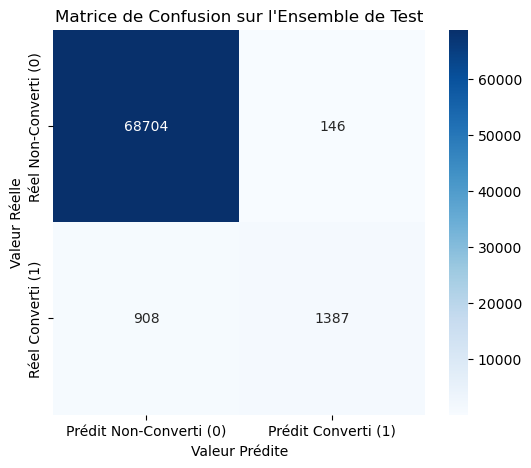

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenir les prédictions sur l'ensemble de test
best_model = gridsearch.best_estimator_
y_pred = best_model.predict(X_test)

# 2. Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matrice de Confusion :")
print(cm)

# 3. Visualisation (Optionnel)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', 
            xticklabels=['Prédit Non-Converti (0)', 'Prédit Converti (1)'],
            yticklabels=['Réel Non-Converti (0)', 'Réel Converti (1)'])
plt.ylabel('Valeur Réelle')
plt.xlabel('Valeur Prédite')
plt.title('Matrice de Confusion sur l\'Ensemble de Test')
plt.show()

In [11]:
scores_df

,model,accuracy,set
0,random_forest,0.986608,train
1,random_forest,0.985374,test


In [3]:
# Perform grid search
print("Grid search...")
xgboost = XGBClassifier()

# Grid of values to be tested
params = {
    'max_depth': [4, 6, 8, 10],
    'min_child_weight': [1, 2, 4, 6, 8],
    'n_estimators': [2, 4, 6, 8, 10, 12]
}
print(params)
gridsearch = GridSearchCV(xgboost, param_grid = params, cv = 3, verbose = 1) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, y_test))

# scores_df = scores_df.append({'model': 'xgboost', 'accuracy': gridsearch.score(X_train, y_train), 'set': 'train'}, ignore_index = True)
# scores_df = scores_df.append({'model': 'xgboost', 'accuracy': gridsearch.score(X_test, y_test), 'set': 'test'}, ignore_index = True)
# scores_df

new_rows = [
    {'model': 'xgboost', 'accuracy': gridsearch.score(X_train, y_train), 'set': 'train'},
    {'model': 'xgboost', 'accuracy': gridsearch.score(X_test, y_test), 'set': 'test'}
]

scores_df = pd.concat([scores_df, pd.DataFrame(new_rows)], ignore_index=True)
scores_df


Grid search...
{'max_depth': [4, 6, 8, 10], 'min_child_weight': [1, 2, 4, 6, 8], 'n_estimators': [2, 4, 6, 8, 10, 12]}
Fitting 3 folds for each of 120 candidates, totalling 360 fits
...Done.
Best hyperparameters :  {'max_depth': 8, 'min_child_weight': 8, 'n_estimators': 12}
Best validation accuracy :  0.9861222386206574

Accuracy on training set :  0.9863986693841217
Accuracy on test set :  0.985494412818891


,model,accuracy,set
0,random_forest,0.987026,train
1,random_forest,0.985508,test
2,xgboost,0.986399,train
3,xgboost,0.985494,test
